# Dataset Exploratory Data Analysis

This notebook performs exploratory data analysis on the animal classification dataset.

## 1. Import Libraries

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm import tqdm

## 2. Dataset Configuration

In [2]:
# Dataset path
DATA_DIR = "../raw-img"

# Italian to English class mapping
ITALIAN_TO_ENGLISH = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel"
}

## 3. Folder Structure

In [3]:
# Display folder structure
print("Dataset folder structure:")
print()
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    indent = ' ' * 4 * level
    folder_name = os.path.basename(root)
    if folder_name:
        print(f"{indent}{folder_name}/")

Dataset folder structure:

raw-img/
    cane/
    cavallo/
    elefante/
    farfalla/
    gallina/
    gatto/
    mucca/
    pecora/
    ragno/
    scoiattolo/


## 4. Class Distribution Analysis

In [4]:
# Count images per class
classes = sorted(os.listdir(DATA_DIR))
class_counts = {}

print("Image count per class:")
print("-" * 50)

for cls in classes:
    class_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(class_path):
        count = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
        eng_name = ITALIAN_TO_ENGLISH.get(cls, cls)
        class_counts[eng_name] = count
        print(f"{eng_name:15s} ({cls:12s}): {count:5d} images")

print("-" * 50)
total = sum(class_counts.values())
print(f"Total images: {total}")

Image count per class:
--------------------------------------------------
dog             (cane        ):  4863 images
horse           (cavallo     ):  2623 images
elephant        (elefante    ):  1446 images
butterfly       (farfalla    ):  2112 images
chicken         (gallina     ):  3098 images
cat             (gatto       ):  1668 images
cow             (mucca       ):  1866 images
sheep           (pecora      ):  1820 images
spider          (ragno       ):  4821 images
squirrel        (scoiattolo  ):  1862 images
--------------------------------------------------
Total images: 26179


## 5. Class Distribution Visualization

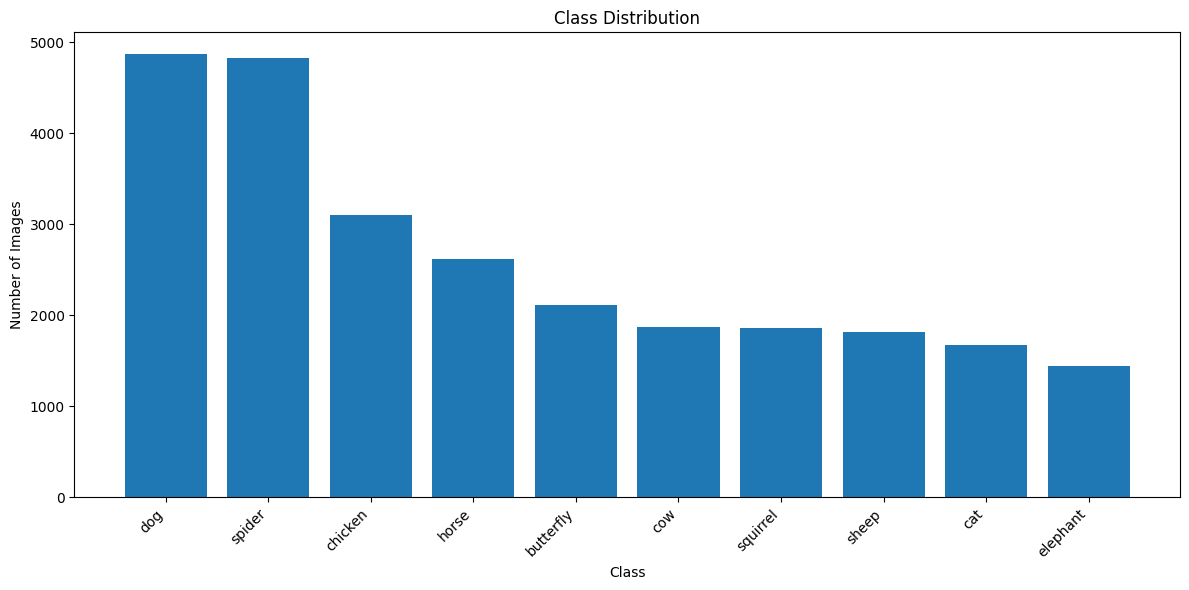

In [5]:
# Create bar chart
plt.figure(figsize=(12, 6))
data_series = pd.Series(class_counts).sort_values(ascending=False)
plt.bar(data_series.index, data_series.values)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. File Extension Analysis

In [6]:
# Check file extensions for each class
print("File extensions per class:")
print("-" * 50)

for cls in classes:
    class_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(class_path):
        files = os.listdir(class_path)
        extensions = [os.path.splitext(f)[1].lower() for f in files if os.path.isfile(os.path.join(class_path, f))]
        ext_counts = pd.Series(extensions).value_counts()
        
        eng_name = ITALIAN_TO_ENGLISH.get(cls, cls)
        print(f"\n{eng_name} ({cls}):")
        for ext, count in ext_counts.items():
            print(f"  {ext}: {count}")

File extensions per class:
--------------------------------------------------

dog (cane):
  .jpeg: 4863

horse (cavallo):
  .jpeg: 2623

elephant (elefante):
  .jpeg: 1079
  .jpg: 359
  .png: 8

butterfly (farfalla):
  .jpeg: 1650
  .jpg: 422
  .png: 40

chicken (gallina):
  .jpeg: 3098

cat (gatto):
  .jpeg: 1227
  .jpg: 440
  .png: 1

cow (mucca):
  .jpeg: 1866

sheep (pecora):
  .jpeg: 1444
  .jpg: 376

spider (ragno):
  .jpeg: 4497
  .jpg: 322
  .png: 2

squirrel (scoiattolo):
  .jpeg: 1862


## 7. Image Dimensions Analysis

In [7]:
# Sample images from each class and check dimensions
print("Analyzing image dimensions (sampling 10 images per class)...")
print("-" * 50)

all_widths = []
all_heights = []

for cls in classes:
    class_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(class_path):
        files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
        sample_files = random.sample(files, min(10, len(files)))
        
        widths = []
        heights = []
        
        for file in sample_files:
            try:
                img_path = os.path.join(class_path, file)
                img = Image.open(img_path)
                width, height = img.size
                widths.append(width)
                heights.append(height)
                all_widths.append(width)
                all_heights.append(height)
            except:
                pass
        
        if widths and heights:
            eng_name = ITALIAN_TO_ENGLISH.get(cls, cls)
            print(f"{eng_name:15s}: width {np.mean(widths):6.1f}±{np.std(widths):5.1f}, height {np.mean(heights):6.1f}±{np.std(heights):5.1f}")

print("-" * 50)
print(f"Overall average: width {np.mean(all_widths):.1f}±{np.std(all_widths):.1f}, height {np.mean(all_heights):.1f}±{np.std(all_heights):.1f}")

Analyzing image dimensions (sampling 10 images per class)...
--------------------------------------------------
dog            : width  282.7± 34.3, height  227.6± 43.4
horse          : width  275.9± 37.9, height  235.9± 43.9
elephant       : width  402.0±155.8, height  281.8±114.2
butterfly      : width  355.0±147.6, height  289.2±116.7
chicken        : width  297.5±  7.5, height  227.9± 47.0
cat            : width  368.0±136.0, height  248.2±104.6
cow            : width  300.0±  0.0, height  211.8± 47.8
sheep          : width  402.0±155.8, height  274.6±100.8
spider         : width  319.0±115.3, height  259.2± 48.7
squirrel       : width  294.5± 16.5, height  213.4± 37.6
--------------------------------------------------
Overall average: width 329.7±112.3, height 247.0±81.8


## 8. Sample Images Visualization

Displaying sample images from each class...


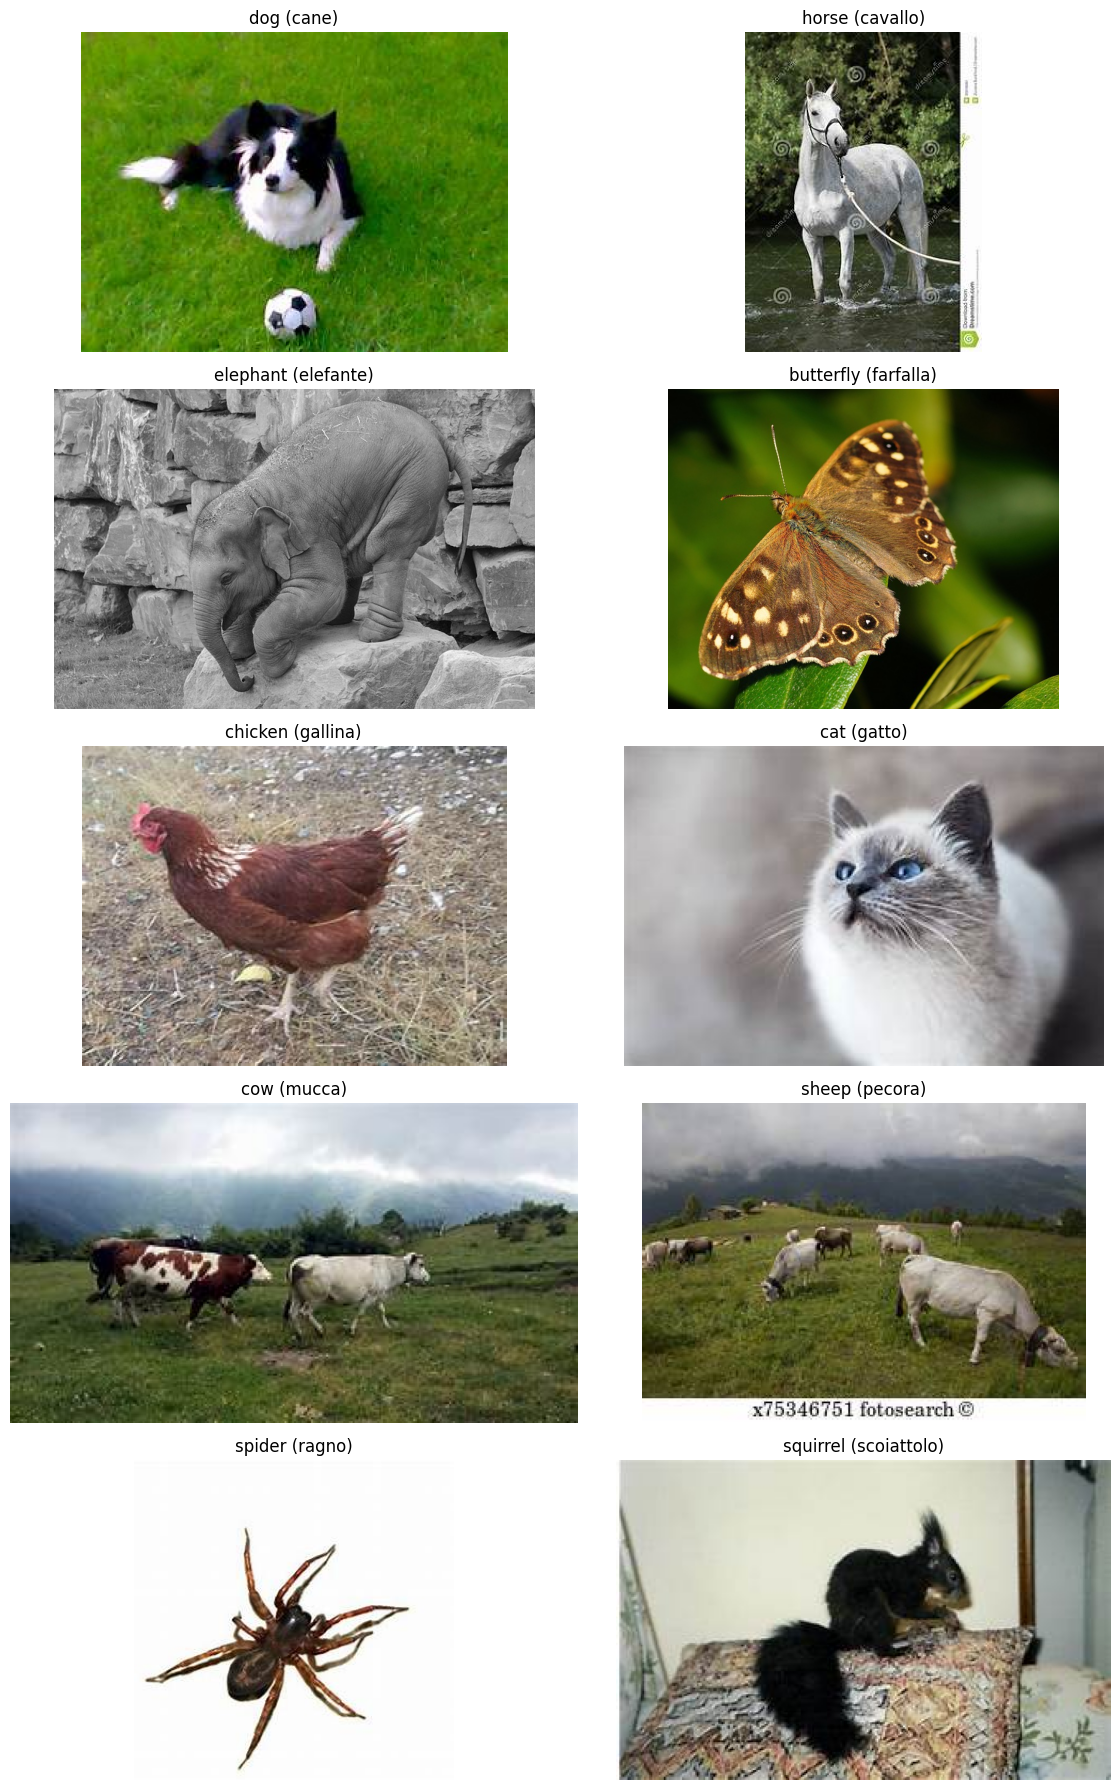

In [8]:
# Display sample images from each class
print("Displaying sample images from each class...")

fig, axes = plt.subplots(5, 2, figsize=(12, 18))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    class_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(class_path):
        files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
        if files:
            sample_file = random.choice(files)
            img_path = os.path.join(class_path, sample_file)
            
            try:
                img = Image.open(img_path).convert('RGB')
                axes[idx].imshow(img)
                eng_name = ITALIAN_TO_ENGLISH.get(cls, cls)
                axes[idx].set_title(f"{eng_name} ({cls})")
                axes[idx].axis('off')
            except:
                axes[idx].text(0.5, 0.5, 'Error loading image', ha='center', va='center')
                axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 9. Multiple Samples Per Class

Displaying 4 random samples from class: dog


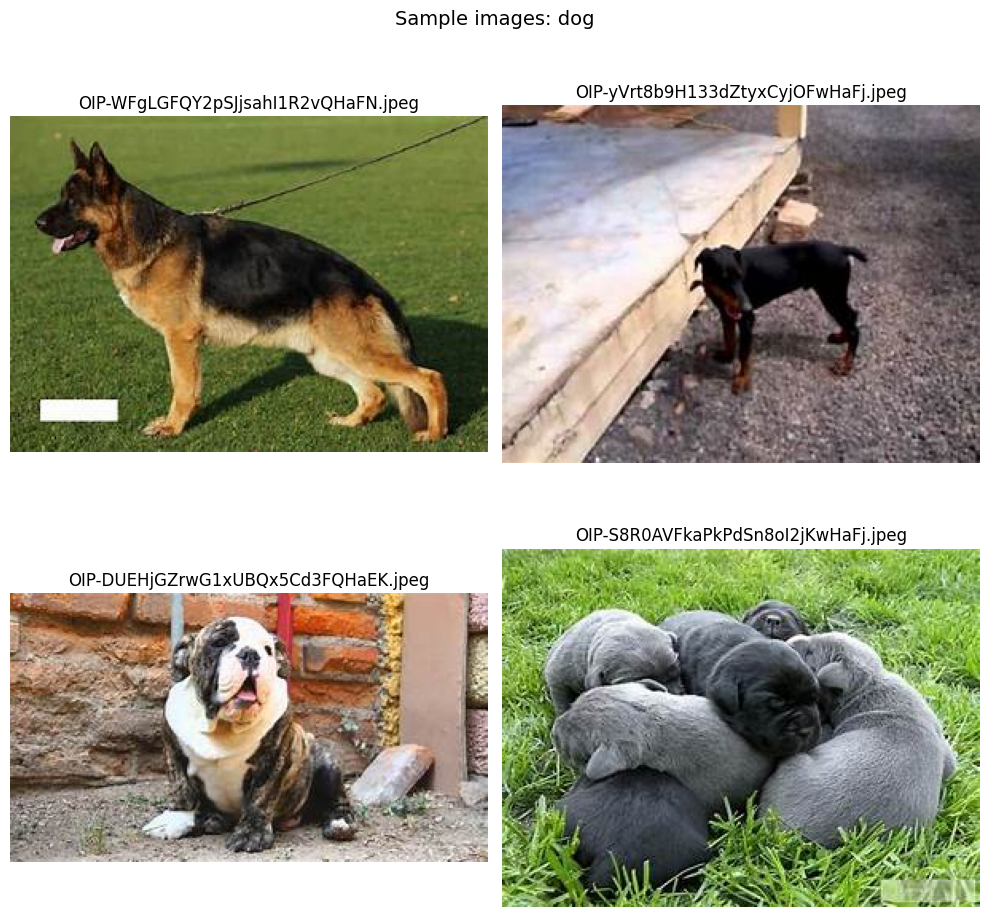

In [9]:
# Display 4 random samples from one class (e.g., dog)
sample_class = "cane"  # Change to any class name
class_path = os.path.join(DATA_DIR, sample_class)
eng_name = ITALIAN_TO_ENGLISH.get(sample_class, sample_class)

print(f"Displaying 4 random samples from class: {eng_name}")

if os.path.isdir(class_path):
    files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    sample_files = random.sample(files, min(4, len(files)))
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()
    
    for idx, file in enumerate(sample_files):
        img_path = os.path.join(class_path, file)
        try:
            img = Image.open(img_path).convert('RGB')
            axes[idx].imshow(img)
            axes[idx].set_title(file)
            axes[idx].axis('off')
        except:
            axes[idx].text(0.5, 0.5, 'Error loading image', ha='center', va='center')
            axes[idx].axis('off')
    
    plt.suptitle(f"Sample images: {eng_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

## 10. Summary Statistics

In [10]:
# Create summary dataframe
summary_data = []

for cls in classes:
    class_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(class_path):
        eng_name = ITALIAN_TO_ENGLISH.get(cls, cls)
        count = class_counts[eng_name]
        percentage = (count / total) * 100
        
        summary_data.append({
            'Italian Name': cls,
            'English Name': eng_name,
            'Image Count': count,
            'Percentage': f"{percentage:.2f}%"
        })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Image Count', ascending=False).reset_index(drop=True)

print("\nDataset Summary:")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)
print(f"Total images: {total}")
print(f"Number of classes: {len(classes)}")
print(f"Average images per class: {total/len(classes):.1f}")


Dataset Summary:
Italian Name English Name  Image Count Percentage
        cane          dog         4863     18.58%
       ragno       spider         4821     18.42%
     gallina      chicken         3098     11.83%
     cavallo        horse         2623     10.02%
    farfalla    butterfly         2112      8.07%
       mucca          cow         1866      7.13%
  scoiattolo     squirrel         1862      7.11%
      pecora        sheep         1820      6.95%
       gatto          cat         1668      6.37%
    elefante     elephant         1446      5.52%
Total images: 26179
Number of classes: 10
Average images per class: 2617.9
